<a href="https://colab.research.google.com/github/rsekola/Projet_data/blob/master/R%C3%A8gles%20des%20associations%20non%20supervis%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/Microsoft_malware_dataset_min.csv")
df.shape
df.head()
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   HasDetections               100000 non-null  int64  
 1   Wdft_IsGamer                96585 non-null   float64
 2   Census_IsVirtualDevice      99815 non-null   float64
 3   Census_OSEdition            100000 non-null  object 
 4   Census_HasOpticalDiskDrive  100000 non-null  int64  
 5   Firewall                    98924 non-null   float64
 6   SMode                       94068 non-null   float64
 7   IsProtected                 99609 non-null   float64
 8   OsPlatformSubRelease        100000 non-null  object 
 9   CountryIdentifier           100000 non-null  int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 7.6+ MB


,HasDetections,Wdft_IsGamer,Census_IsVirtualDevice,Census_OSEdition,Census_HasOpticalDiskDrive,Firewall,SMode,IsProtected,OsPlatformSubRelease,CountryIdentifier
count,100000.000000,96585.000000,99815.000000,100000,100000.000000,98924.000000,94068.000000,99609.000000,100000,100000.000000
unique,NaN,NaN,NaN,19,NaN,NaN,NaN,NaN,9,NaN
top,NaN,NaN,NaN,Core,NaN,NaN,NaN,NaN,rs4,NaN
freq,NaN,NaN,NaN,38727,NaN,NaN,NaN,NaN,43955,NaN
mean,0.499280,0.281607,0.006642,NaN,0.075850,0.977326,0.000351,0.944864,NaN,108.188050
std,0.500002,0.449785,0.081230,NaN,0.264759,0.148863,0.018727,0.228246,NaN,62.989406
min,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000
25%,0.000000,0.000000,0.000000,NaN,0.000000,1.000000,0.000000,1.000000,NaN,51.000000
50%,0.000000,0.000000,0.000000,NaN,0.000000,1.000000,0.000000,1.000000,NaN,97.000000
75%,1.000000,1.000000,0.000000,NaN,0.000000,1.000000,0.000000,1.000000,NaN,162.000000


In [3]:
pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00


In [4]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Microsoft Malware Profiling Report")
profile.to_file("malware_report.html")
df.isnull().sum().sort_values(ascending=False)
# Numériques
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Catégorielles
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("Unknown")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:02<00:00,  3.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
df.duplicated().sum()
df = df.drop_duplicates()



In [7]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]



In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [9]:
X = df.drop("HasDetections", axis=1)  # variable cible
y = df["HasDetections"]


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
y.value_counts(normalize=True)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)


In [14]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_resampled)
X_test_selected = selector.transform(X_test_scaled)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)


In [15]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA(n_components=0.95))
])


In [16]:
print("Train shape:", X_train_pca.shape)
print("Test shape:", X_test_pca.shape)
print("Distribution des classes:", np.bincount(y_train_resampled))


Train shape: (6896, 4)
Test shape: (1683, 4)
Distribution des classes: [3448 3448]


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [18]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=20,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)


DecisionTreeClassifier(max_depth=10, min_samples_split=20, random_state=42)

In [19]:
y_test_proba = dt_model.predict_proba(X_test_scaled)[:, 1]


In [20]:
y_test_proba = dt_model.predict_proba(X_test_scaled)[:, 1]


In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

print("AUC :", auc_score)


AUC : 0.44288146850182286


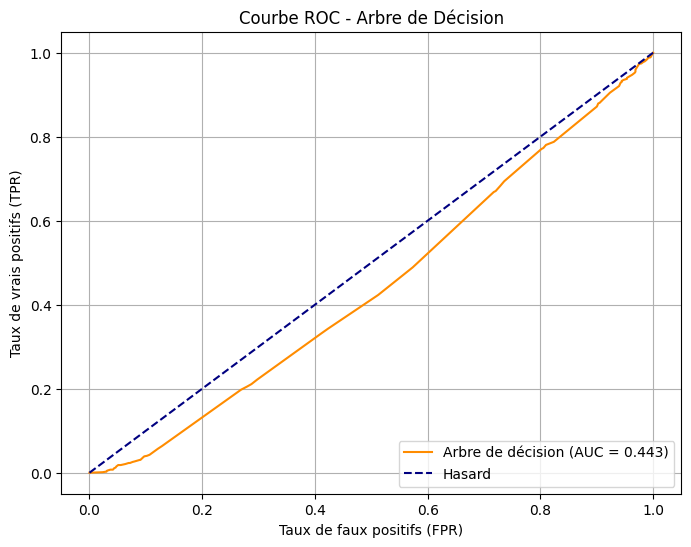

In [22]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange',
         label=f'Arbre de décision (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Hasard')

plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Arbre de Décision')
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_scaled, y_train)

y_base_proba = dt_baseline.predict_proba(X_test_scaled)[:, 1]
auc_baseline = roc_auc_score(y_test, y_base_proba)

print("AUC modèle de base :", auc_baseline)


AUC modèle de base : 0.16383362066529122


In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}


In [25]:
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15, 20],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 10, 20, 50]},
             scoring='roc_auc', verbose=1)

In [26]:
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur AUC CV :", grid_search.best_score_)


Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 20}
Meilleur AUC CV : 0.49495615395909204


In [27]:
best_dt = grid_search.best_estimator_

y_best_proba = best_dt.predict_proba(X_test_scaled)[:, 1]
auc_best = roc_auc_score(y_test, y_best_proba)

print("AUC modèle optimisé :", auc_best)


AUC modèle optimisé : 0.49530777492015937


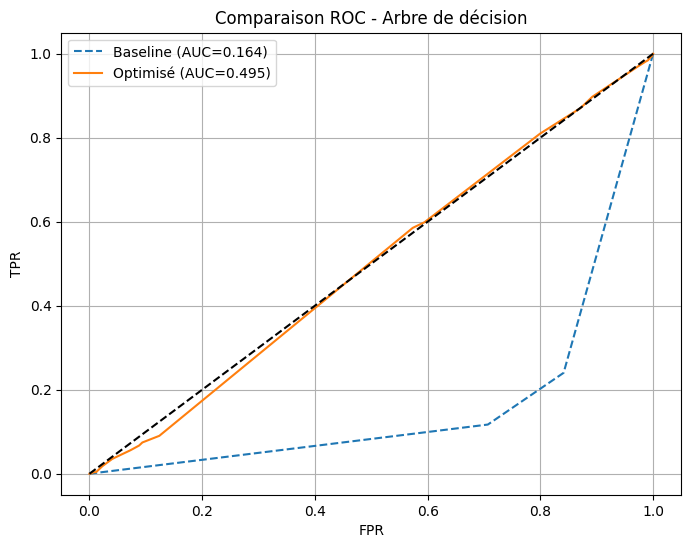

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_base, tpr_base, _ = roc_curve(y_test, y_base_proba)
fpr_best, tpr_best, _ = roc_curve(y_test, y_best_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_base, tpr_base, linestyle='--',
         label=f'Baseline (AUC={auc_baseline:.3f})')

plt.plot(fpr_best, tpr_best,
         label=f'Optimisé (AUC={auc_best:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Comparaison ROC - Arbre de décision')
plt.legend()
plt.grid()
plt.show()


In [30]:
X_unsupervised = df.drop(columns=["HasDetections"])



In [31]:
"HasDetections" in X_unsupervised.columns


False

In [32]:
print("Avant :", df.shape)
print("Après :", X_unsupervised.shape)


Avant : (8412, 10)
Après : (8412, 9)


In [34]:
X_unsupervised.dtypes
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_unsupervised_scaled = scaler.fit_transform(X_unsupervised)


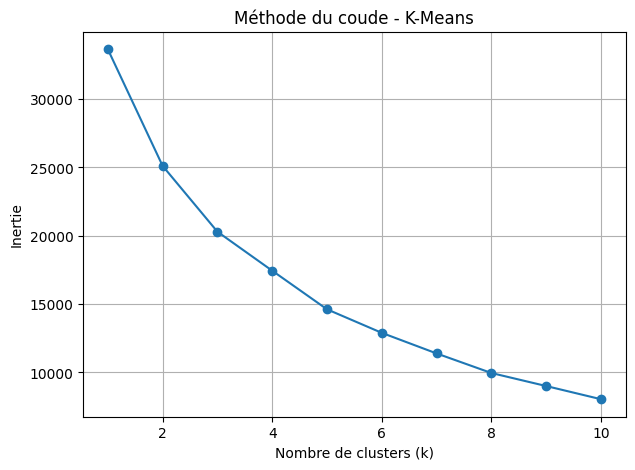

In [35]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_unsupervised_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude - K-Means')
plt.grid()
plt.show()



In [36]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unsupervised_scaled)
X_clusters = X_unsupervised.copy()
X_clusters["Cluster"] = clusters


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_unsupervised_scaled)


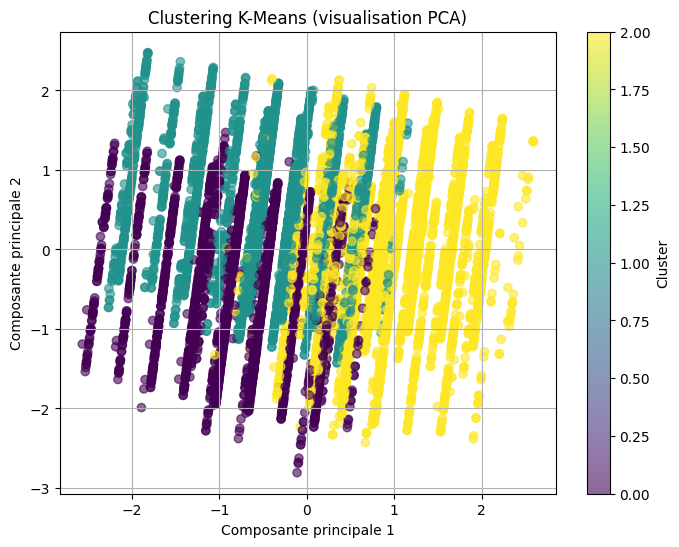

In [38]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Clustering K-Means (visualisation PCA)')
plt.colorbar(scatter, label='Cluster')
plt.grid()
plt.show()


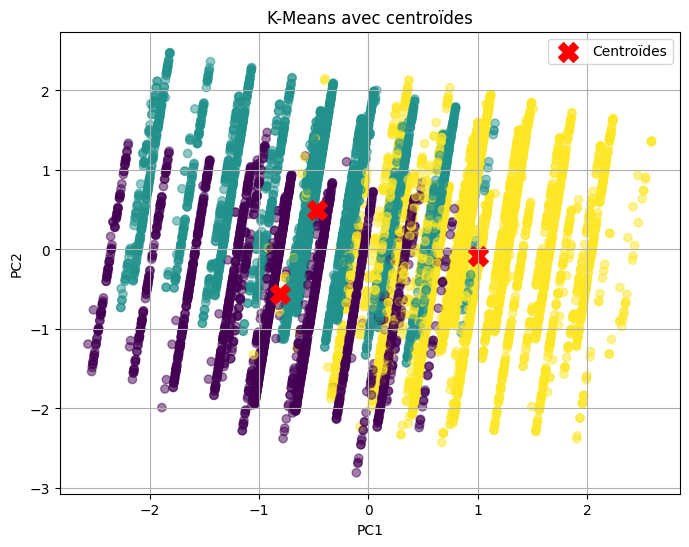

In [39]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=clusters, cmap='viridis', alpha=0.5)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', s=200, marker='X', label='Centroïdes')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means avec centroïdes')
plt.legend()
plt.grid()
plt.show()


In [40]:
pd.crosstab(df["HasDetections"], X_clusters["Cluster"])


Cluster,0,1,2
HasDetections,,,
0,1104,1575,1632
1,1086,1445,1570


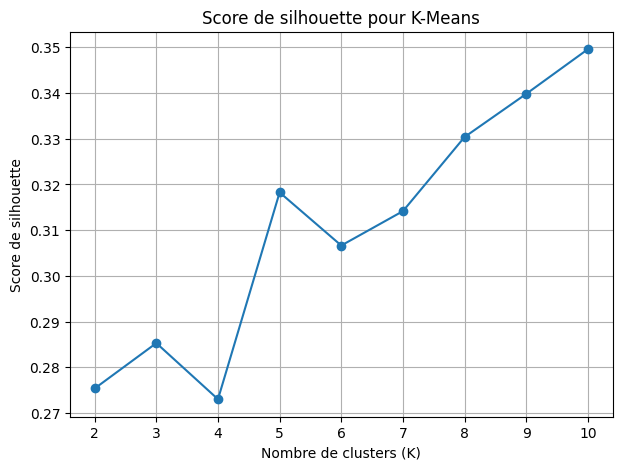

In [42]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):  # silhouette non définie pour K=1
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_unsupervised_scaled)
    score = silhouette_score(X_unsupervised_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette pour K-Means')
plt.grid()
plt.show()

